<a href="https://colab.research.google.com/github/banteamlak1888/Floridan-University-Fundamentals-AI-Trianing/blob/main/Heart_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd #for numerical computing in Python
import numpy as np  #Data manipulation and analysis library
import matplotlib.pyplot as plt #plotting and visualization library
import seaborn as sns #Statistical data visualization based on Matplotlib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
data = pd.read_csv("Heart_Disease_Prediction.csv")
data.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [ ]:
#Step 3: Explore Data, Understand structure, types, and missing values.
data.shape
data.info()
data.isnull().sum()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    int64  
dtypes: float64(1), int64(13)
m

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000


In [ ]:
data["Heart Disease"] = data["Heart Disease"].map({
    1:"Presence",
    0:"Absence"
})

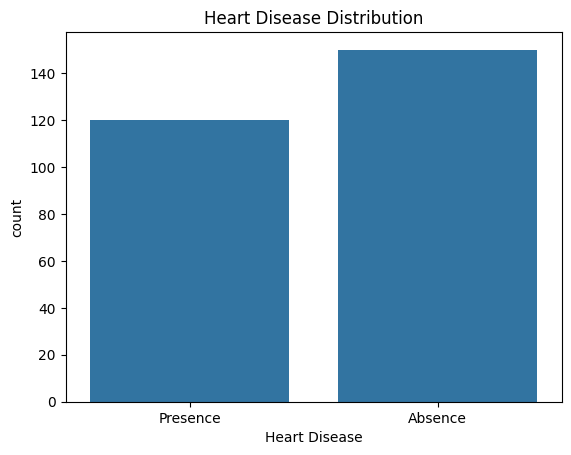

In [ ]:
sns.countplot(x="Heart Disease", data=data)
plt.title("Heart Disease Distribution")
plt.show()

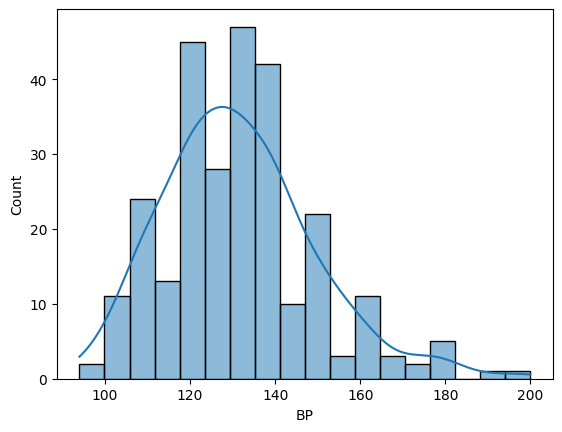

In [ ]:
sns.histplot(data['BP'], kde=True)
plt.show()

In [ ]:
#Step 6: Define Features and Target
X = data.drop('Heart Disease', axis=1)
y = data['Heart Disease']

In [ ]:
#Step 7: Identify Categorical and Numerical Columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index([], dtype='object')

Numerical Columns:
Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')


In [ ]:
#Step 8: Data Preprocessing
#- Handle missing values
#- Encode categorical variables
#- Scale numerical features
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

In [ ]:
print("Numerical Pipeline:")
print(num_pipeline)

print("\nCategorical Pipeline:")
print(cat_pipeline)

print("\nCombined Preprocessor:")
print(preprocessor)

Numerical Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

Categorical Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

Combined Preprocessor:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  S

In [ ]:
print("Numerical columns:", list(numerical_cols))
print("Categorical columns:", list(categorical_cols))

Numerical columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
Categorical columns: []


In [ ]:
#Step 9: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Step 10: Define Machine Learning Models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}


Model: Logistic Regression
Accuracy: 0.9074074074074074
              precision    recall  f1-score   support

     Absence       0.91      0.94      0.93        33
    Presence       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



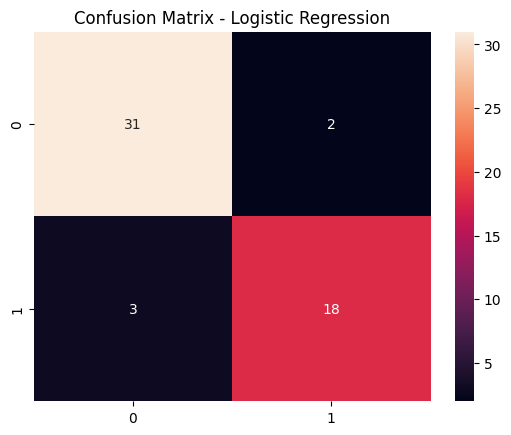


Model: Decision Tree
Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

     Absence       0.78      0.64      0.70        33
    Presence       0.56      0.71      0.62        21

    accuracy                           0.67        54
   macro avg       0.67      0.68      0.66        54
weighted avg       0.69      0.67      0.67        54



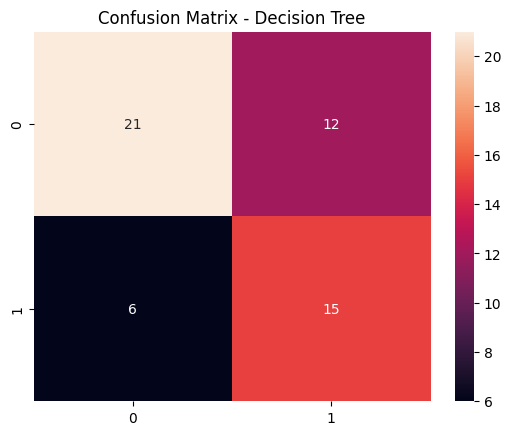


Model: Random Forest
Accuracy: 0.8518518518518519
              precision    recall  f1-score   support

     Absence       0.84      0.94      0.89        33
    Presence       0.88      0.71      0.79        21

    accuracy                           0.85        54
   macro avg       0.86      0.83      0.84        54
weighted avg       0.86      0.85      0.85        54



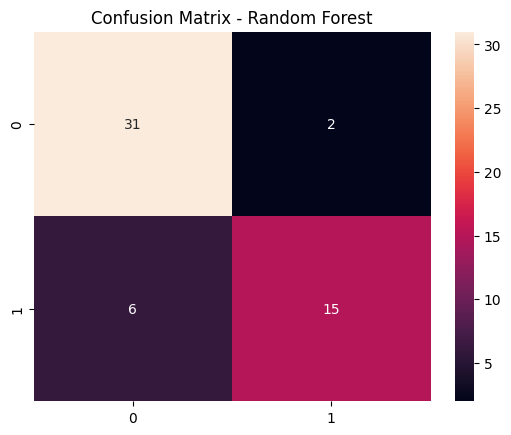

In [ ]:
#Step 11: Train and Evaluate Models
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"\nModel: {name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    results.append((name, acc))

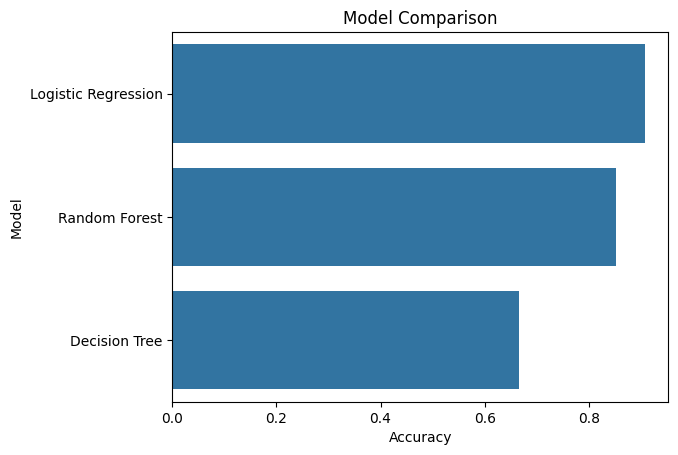

In [ ]:
#Step 12: Compare Models
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df
sns.barplot(x="Accuracy", y="Model", data=results_df)
plt.title("Model Comparison")
plt.show()

In [ ]:
# Predict on test data
y_pred = pipeline.predict(X_test)

print("Predictions on test data:")
print(y_pred[:10])   # first 10 predictions

print("\nActual values:")
print(y_test[:10].values)   # first 10 real values

Predictions on test data:
['Absence' 'Presence' 'Absence' 'Absence' 'Absence' 'Presence' 'Absence'
 'Absence' 'Absence' 'Absence']

Actual values:
['Presence' 'Presence' 'Absence' 'Absence' 'Absence' 'Presence' 'Absence'
 'Absence' 'Absence' 'Absence']


In [ ]:
results_compare = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results_compare.head(10))

     Actual Predicted
0  Presence   Absence
1  Presence  Presence
2   Absence   Absence
3   Absence   Absence
4   Absence   Absence
5  Presence  Presence
6   Absence   Absence
7   Absence   Absence
8   Absence   Absence
9   Absence   Absence


In [ ]:
new_data = pd.DataFrame([{
    'ID': 1,
    'Age': 60,
    'Sex': 'Male',
    'Chest pain type': 4,
    'BP': 140,
    'Cholesterol': 293,
    'FBS over 120': 0,
    'EKG results': 2,
    'Max HR': 170,
    'Exercise angina': 0,
    'ST depression': 1.2,
    'Slope of ST': 2,
    'Number of vessels fluro': 2,
    'Thallium': 7
}])

user_prediction = pipeline.predict(new_data)
print("Prediction for new user input:", user_prediction[0])

Prediction for new user input: Presence


In [ ]:
user_prediction_proba = pipeline.predict_proba(new_data)

print("Prediction probabilities:", user_prediction_proba)

Prediction probabilities: [[0.05 0.95]]
